In [1]:
#preserved concepts
!pip install numpy==1.26.4
import numpy as np
print(np.version.version)
!pip install pandas
import concept_getters
import pandas as pd
import re
import os
SPARSITY_RATIOS_LTH = [0.0, 25.0, 43.75, 57.81, 68.36, 76.27]
SPARSITY_RATIOS_WANDA = [0.0, 25.0, 43.75, 57.81, 68.36, 76.27]
expl_clus=3
import collections

def get_indiv_concepts_per_unit(df) -> dict:
    concepts = {}
    for unit,expl in zip(df.unit, df.best_name):
        concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', expl)
        for i in range(len(concps)):
            while concps[i][-1] == ')':
                concps[i] = concps[i][:-1]
        concepts[unit] = concps
    return concepts

def get_concepts_across_pruning_per_neuron(model, method, filename, sparsity_list,expl_clus):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(dict)
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            reordered[neuron][sparsity] = concepts
    return reordered 

def get_concepts_assoc_sparsities(model, method, filename, sparsity_list,expl_clus):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(lambda: collections.defaultdict(set))
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            for concept in concepts:
                reordered[neuron][concept].add(sparsity)
    return reordered 

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Obtaining dependency information for numpy==1.26.4 from https://files.pythonhosted.org/packages/4b/d7/ecf66c1cd12dc28b4040b15ab4d17b773b87fa9d29ca16125de01adb36cd/numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 192.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.22.2
    Uninstalling numpy-1.22.2:
      Successfully uninstalled numpy-1.22.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.57.1+1.g5fba9aa8f requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.
torch-tensorrt 2.0.0.dev0 requires torch<=2.1.0,>=2.0.0, but you have torch 2.2.2 w

In [24]:
df=pd.read_csv("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run0.25/Expls/57.812%Pruned/Cluster3IOUS1024N.csv")


In [25]:
def count_frequencies(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
  

unique_concepts =set()
def num_unique_concepts_for_a_neuron(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    for concept in concept_freq:
        unique_concepts.add()
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
                
        
        

In [ ]:
model="BERT"
bert_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run0.25'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,6):
    num_orig_cps = get_num_concpets_explained_originally(method, filename,expl_clus)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list,expl_clus)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename, sparsity_list,expl_clus)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth.append(percent_of_concepts_preserved)


In [2]:
def total_num_concepts(iteration_root):
    concpets = []
    for pi in os.listdir(iteration_root):
        if 'result' in pi or '.ipynb' in pi: continue
        df = pd.read_csv(os.path.join(iteration_root, pi))
        unique=get_indiv_concepts_per_unit(df)
        concpets.extend(unique)
    return len(concpets)
def get_all_concepts(iteration):
    count=0
    for cluster in os.listdir(iteration):
        if 'result.csv' in cluster or '.ipy' in cluster:  continue
        indiv_concepts = get_indiv_concepts_per_unit(pd.read_csv(os.path.join(iteration, cluster))).values()
        for concept in indiv_concepts:
            for cp in concept:
                if 'oth:' in cp:
                    count += 1 
    return count
othcps = {}      
for method in ['wanda', 'lottery_ticket']:
    for model in ['BERT', 'BOWMAN', 'LLAMA']:
        root=f"/workspace/CCE_NLI/{model}/exp/{method}/Run0.25/Expls"
        for pi in os.listdir(root):
            if '.ipy' in pi: continue
            count = get_all_concepts(os.path.join(root,pi))
            total=total_num_concepts(os.path.join(root,pi))
            print(f"{model}_{method}_{pi}: {count}/{total}")
            othcps[f"{model}_{method}_{pi}"]=count/total
#number of unique concpets says same in bert (lth and wanda) and llama lottery  (ll 1024). in bowman and llama wanda the umber of unique concepts increases with pruning 

BERT_wanda_0.0%Pruned: 267/2805
BERT_wanda_25.0%Pruned: 270/2800
BERT_wanda_43.75%Pruned: 245/2812
BERT_wanda_57.812%Pruned: 225/2824
BERT_wanda_68.359%Pruned: 239/2842
BERT_wanda_76.27%Pruned: 275/2865
BOWMAN_wanda_0.0%Pruned: 5/32
BOWMAN_wanda_25.0%Pruned: 9/42
BOWMAN_wanda_43.75%Pruned: 24/131
BOWMAN_wanda_57.812%Pruned: 20/99
BOWMAN_wanda_68.359%Pruned: 27/164
BOWMAN_wanda_76.27%Pruned: 22/141


FileNotFoundError: [Errno 2] No such file or directory: '/workspace/CCE_NLI/LLAMA/exp/wanda/Run0.25/Expls'

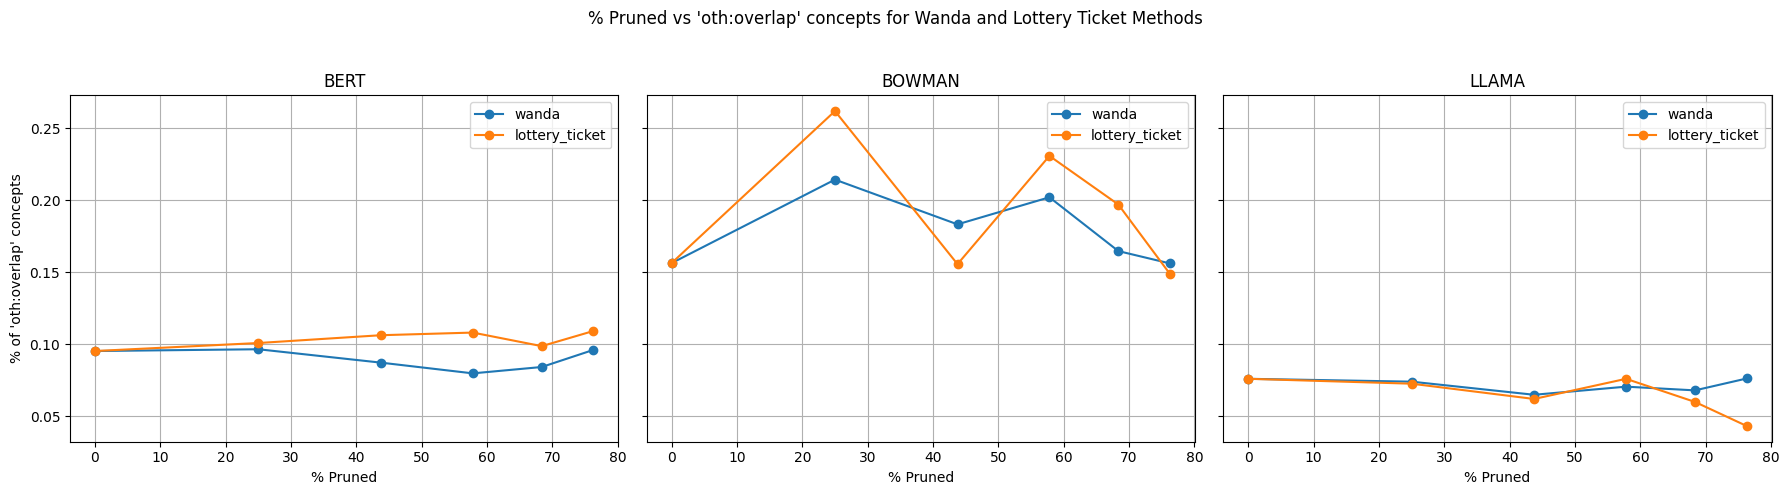

In [54]:
models = ['BERT', 'BOWMAN', 'LLAMA']
methods = ['wanda', 'lottery_ticket']
structured = {m: {meth: [] for meth in methods} for m in models}

pattern = re.compile(r'([A-Z]+)_(wanda|lottery_ticket)_([\d\.]+)%Pruned')

for key, val in othcps.items():
    match = pattern.match(key)
    if match:
        model, method, pruned = match.groups()
        pruned = float(pruned)
        structured[model][method].append((pruned, val))

# Sort each list by pruned %
for model in structured:
    for method in structured[model]:
        structured[model][method].sort(key=lambda x: x[0])

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("% Pruned vs 'oth:overlap' concepts for Wanda and Lottery Ticket Methods")

for i, model in enumerate(models):
    ax = axs[i]
    for method in methods:
        data_points = structured[model][method]
        if data_points:
            x, y = zip(*data_points)
            ax.plot(x, y, marker='o', label=method)
    ax.set_title(model)
    ax.set_xlabel('% Pruned')
    if i == 0:
        ax.set_ylabel("% of 'oth:overlap' concepts")
    ax.legend()
    ax.grid(True)
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6)) 

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

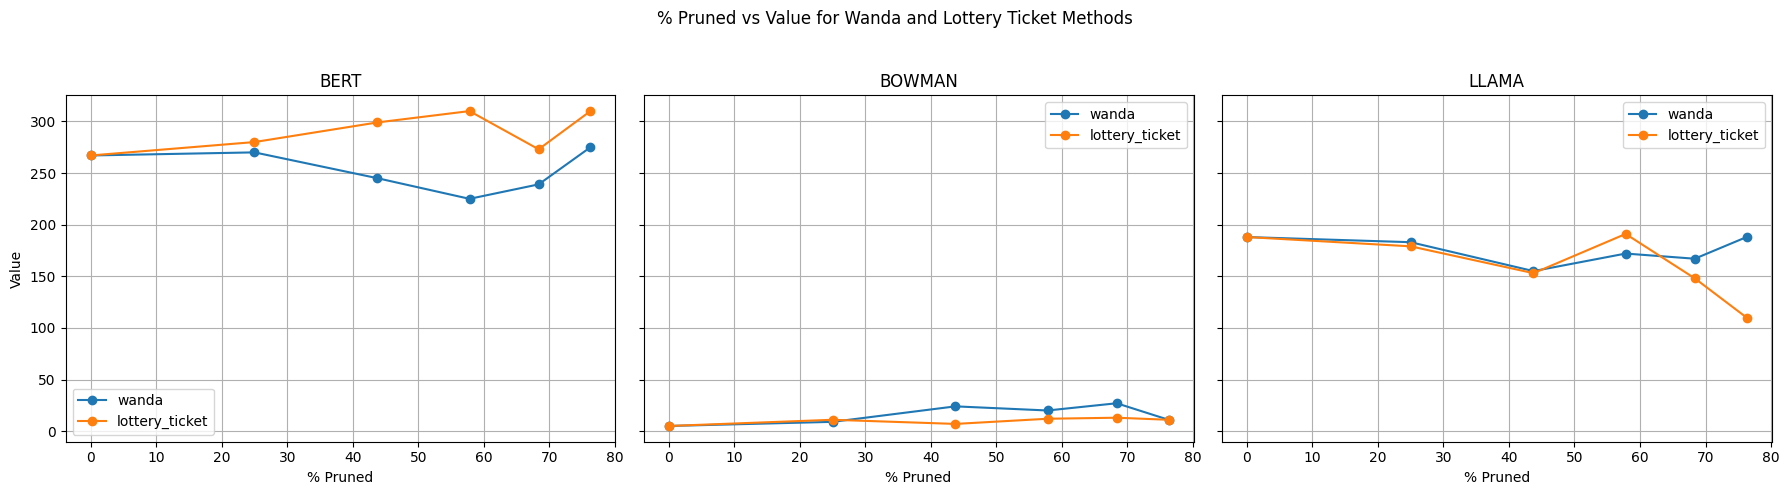

In [41]:
models = ['BERT', 'BOWMAN', 'LLAMA']
methods = ['wanda', 'lottery_ticket']
structured = {m: {meth: [] for meth in methods} for m in models}

pattern = re.compile(r'([A-Z]+)_(wanda|lottery_ticket)_([\d\.]+)%Pruned')

for key, val in othcps.items():
    match = pattern.match(key)
    if match:
        model, method, pruned = match.groups()
        pruned = float(pruned)
        structured[model][method].append((pruned, val))

# Sort each list by pruned %
for model in structured:
    for method in structured[model]:
        structured[model][method].sort(key=lambda x: x[0])

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('% Pruned vs Value for Wanda and Lottery Ticket Methods')

for i, model in enumerate(models):
    ax = axs[i]
    for method in methods:
        data_points = structured[model][method]
        if data_points:
            x, y = zip(*data_points)
            ax.plot(x, y, marker='o', label=method)
    ax.set_title(model)
    ax.set_xlabel('% Pruned')
    if i == 0:
        ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# neuron wise: % of concepts preserved for at least first k iters
so for first 1 iters (ie only 1 iter 0.0%), should be 1.0 (all concepts are preserved for at least 1 iter)

Skipping BOWMAN_wanda_Run0.25 due to error: [Errno 2] No such file or directory: '/workspace/CCE_NLI/BOWMAN/exp/wanda/Run0.25/Expls/76.27%Pruned/Cluster1IOUS1024N.csv'
Skipping BOWMAN_wanda_Run0.25 due to error: [Errno 2] No such file or directory: '/workspace/CCE_NLI/BOWMAN/exp/wanda/Run0.25/Expls/76.27%Pruned/Cluster2IOUS1024N.csv'
Skipping BOWMAN_wanda_Run0.25 due to error: [Errno 2] No such file or directory: '/workspace/CCE_NLI/BOWMAN/exp/wanda/Run0.25/Expls/76.27%Pruned/Cluster3IOUS1024N.csv'
Error in plotting BOWMAN_wanda_Run0.25_1 due to 'BOWMAN_wanda_Run0.25_1'
Error in plotting BOWMAN_wanda_Run0.25_2 due to 'BOWMAN_wanda_Run0.25_2'
Error in plotting BOWMAN_wanda_Run0.25_3 due to 'BOWMAN_wanda_Run0.25_3'


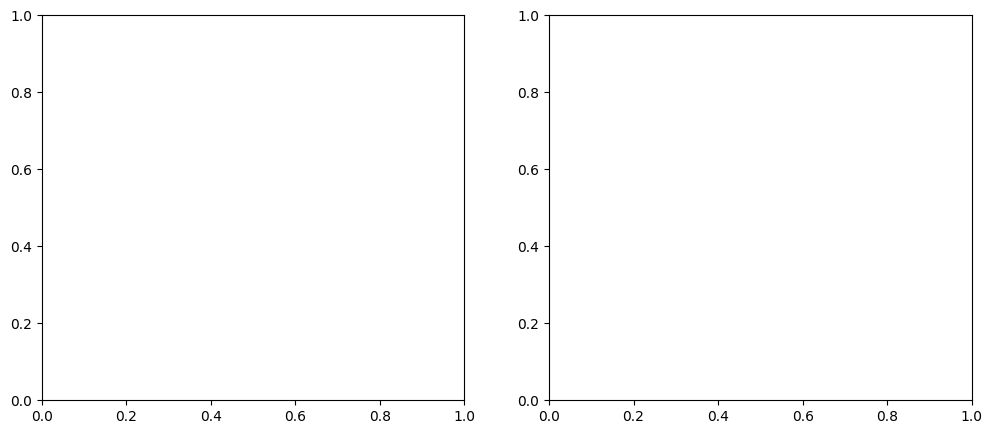

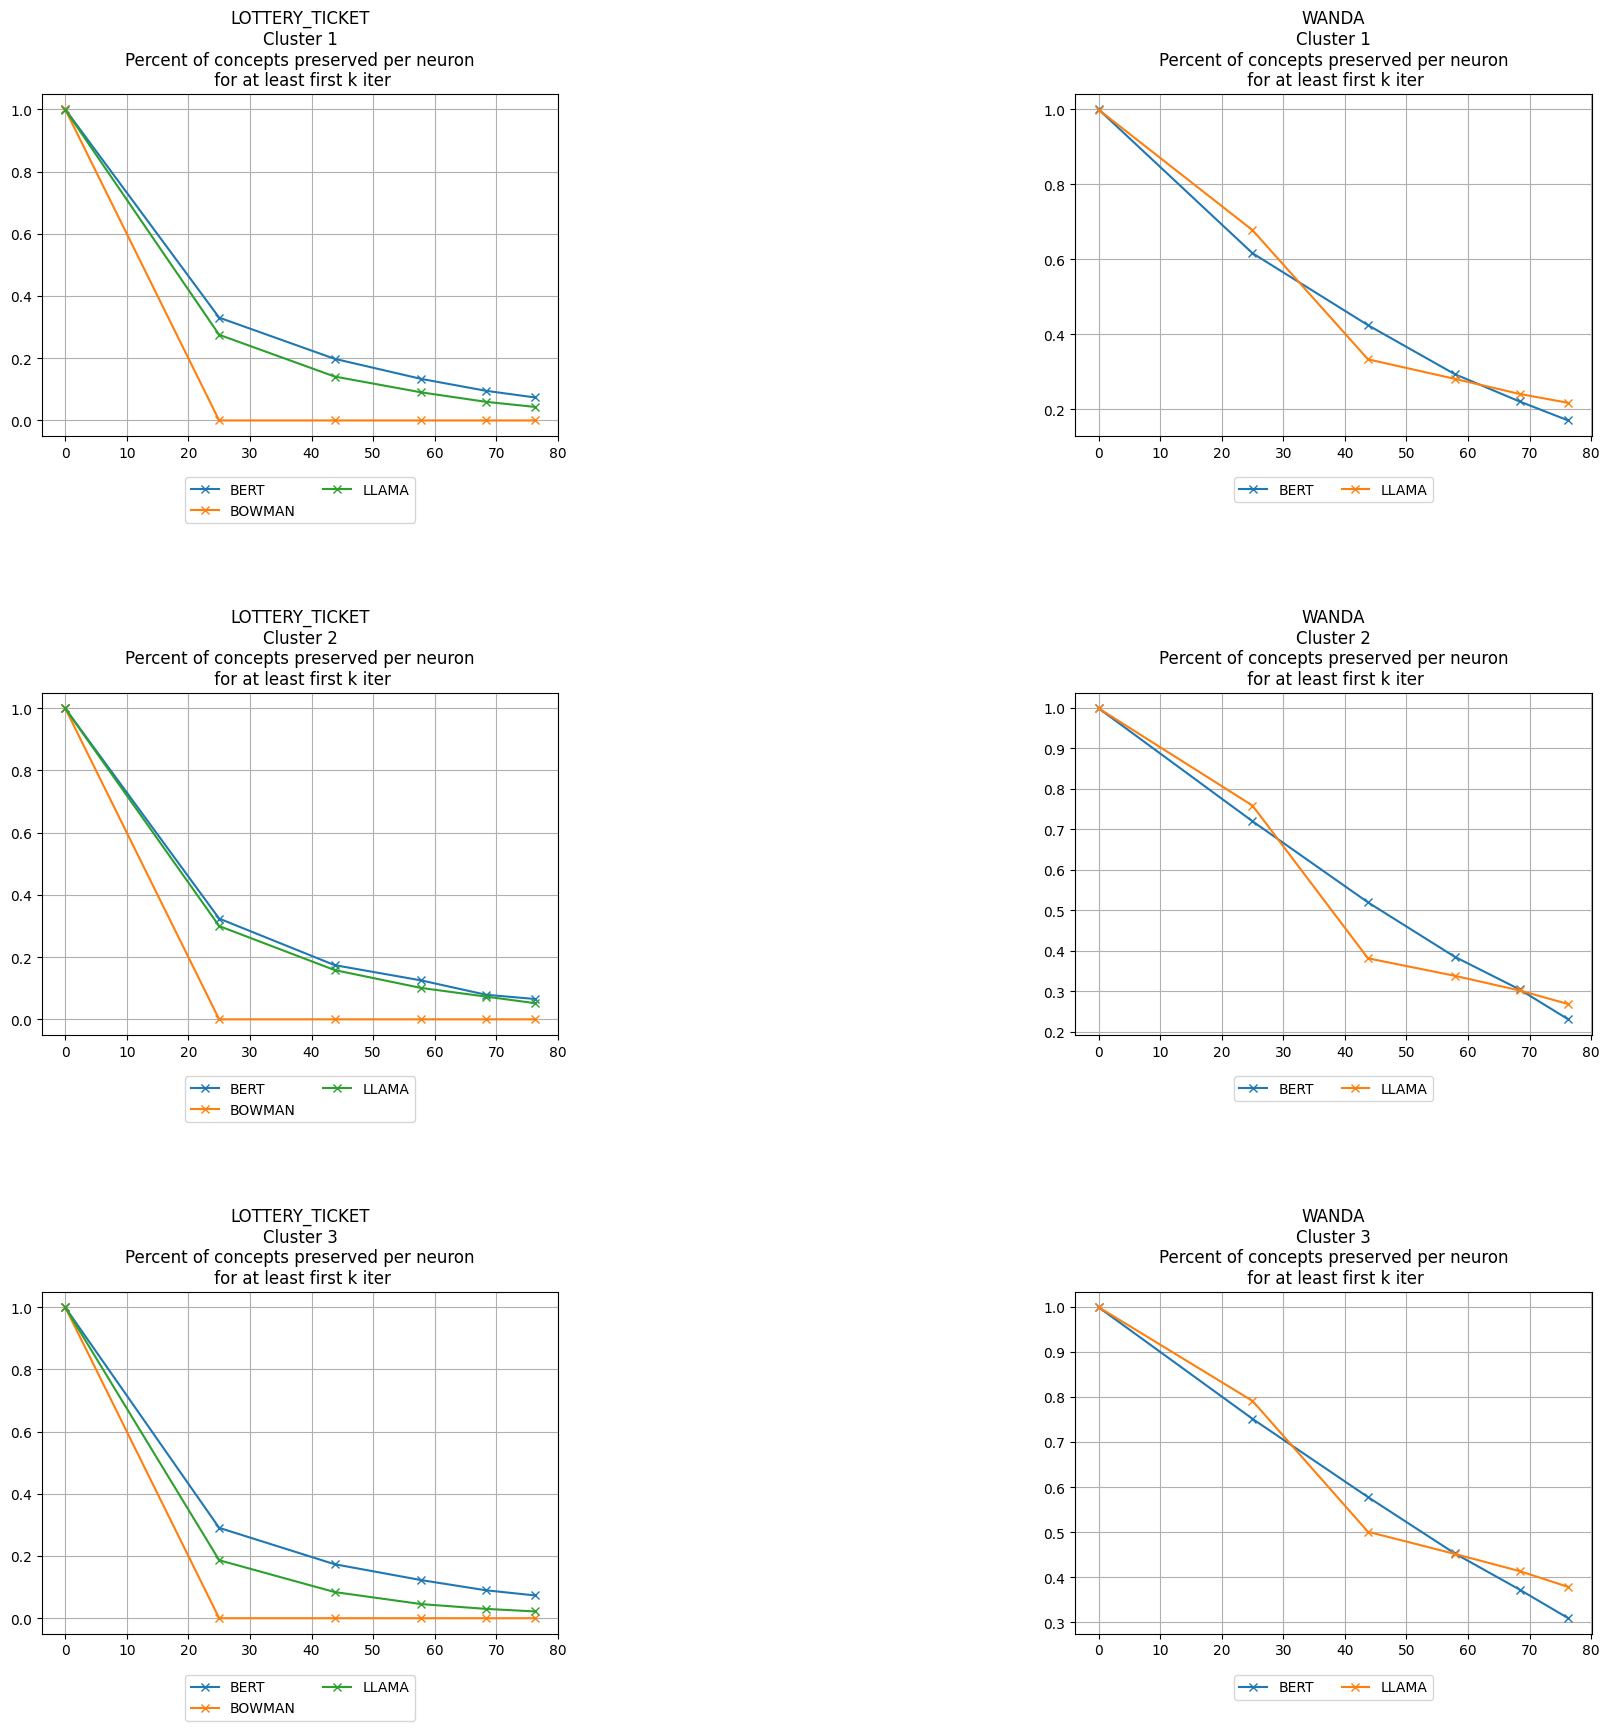

In [27]:
import matplotlib.pyplot as plt
expl_clus=2
def get_num_concpets_explained_originally(method, filename,expl_clus):
    unique_concepts=set()
    explanations = {}
    if filename == 'Random':
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Expls/Cluster{expl_clus}IOUS1024N.csv")
        
    else:
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
    
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    for neuron, concepts in all_concept_at_original.items():
        for concept in concepts:
            unique_concepts.add(concept)
    return len(unique_concepts) 


#looks at each neuron and counts how many concepts are preserved continuously for k iters
    #ex: neuron 0 expls some set of concepts and at different pruning iters (so dog at 0,25,43 then cat at 43, 68 then fih and 0.68 etc)
        #this function counts of the condeps expld original by neuron 0 how many concepts are explain continiously for k iters
        #######so its neuron wise preservation of concepts at a given clustr############
def dropoff(method, filename, k, **kwargs):
    num_orig_cps = kwargs['num_orig_cps']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']

    percent_cocnepts_preserved=[]
    for neuron in sparsity_mapping.keys():
        concepts_preserved=set()
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first k iters
                concepts_preserved.add(concept)
        #print(neuron, len(concepts_preserved), len(sparsity_mapping[neuron][0.0]))
        if 0.0 in sparsity_mapping[neuron].keys():
            percent_cocnepts_preserved.append(len(concepts_preserved)/len(sparsity_mapping[neuron][0.0]))
            
        
    return sum(percent_cocnepts_preserved)/len(percent_cocnepts_preserved)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

def get_sparsities(model, method, filename):
    li=[]
    for s in sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/")):
        if '.ipy' in s: continue
        li.append(float(s.split("%")[0]))
    return li




params = [{'model':'BERT', 'filename': 'Run0.25'}, {'model':'BOWMAN', 'filename': 'Run0.25'}, {'model':'LLAMA', 'filename': 'Run0.25'}]
results={}
for expl_clus in range(1,4):
    for param in params:
        model = param['model']
        filename = param['filename']
        for method in ['wanda', 'lottery_ticket']:
            percent_preserved_with_dropoff = []
            sparsity_list = get_sparsities(model, method, filename)
            try: 
                for k in range(1,7):
                    
                    num_orig_cps = get_num_concpets_explained_originally(method, filename, expl_clus)
                    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list,expl_clus)

                    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename, sparsity_list,expl_clus)
                    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)

                    percent_preserved_with_dropoff.append(percent_of_concepts_preserved)
                results[f"{model}_{method}_{filename}_{expl_clus}"] = percent_preserved_with_dropoff

            except Exception as e:
                print(f"Skipping {model}_{method}_{filename} due to error: {e}")


fig, axs = plt.subplots(3,2,figsize=(20, 20))
for expl in range(1,4):
    r=0
    for i, method in enumerate(['lottery_ticket', 'wanda']):
        for model in ['BERT', 'BOWMAN', 'LLAMA']:
            try:
                axs[expl-1][r].plot(sparsity_list, results[f'{model}_{method}_Run0.25_{expl}'], label=model, marker='x')
            except Exception as e:
                print(f"Error in plotting {model}_{method}_Run0.25_{expl} due to {e}")
        axs[expl-1][r].set_title(f'{method.upper()}\nCluster {expl}\nPercent of concepts preserved per neuron\n for at least first k iter')
        axs[expl-1][r].legend()
        axs[expl-1][r].grid(True)
        axs[expl-1][r].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
        r+=1

fig.subplots_adjust(wspace=1, hspace=0.75)



#so ex 30% of concepts make it to the 3rd pruning iter staying with the same neuron
    
  

In [ ]:
bert_dropoffs_wanda, bert_dropoffs_lth

# % of neurons that preserve concepts for at lesat first k iters

Skipping BERT_wanda_Run0.25 due to error: name 'sparsity_list' is not defined
Skipping BERT_lottery_ticket_Run0.25 due to error: name 'sparsity_list' is not defined
Skipping BOWMAN_wanda_Run0.25 due to error: name 'sparsity_list' is not defined
Skipping BOWMAN_lottery_ticket_Run0.25 due to error: name 'sparsity_list' is not defined
Skipping LLAMA_wanda_Run0.25 due to error: [Errno 2] No such file or directory: '/workspace/CCE_NLI/LLAMA/exp/wanda/Run0.25/Expls/0.0%Pruned/Cluster1IOUS1024N.csv'
Skipping LLAMA_lottery_ticket_Run0.25 due to error: [Errno 2] No such file or directory: '/workspace/CCE_NLI/LLAMA/exp/lottery_ticket/Run0.25/Expls/0.0%Pruned/Cluster1IOUS1024N.csv'
Skipping BERT_wanda_Run0.25 due to error: name 'sparsity_list' is not defined
Skipping BERT_lottery_ticket_Run0.25 due to error: name 'sparsity_list' is not defined
Skipping BOWMAN_wanda_Run0.25 due to error: name 'sparsity_list' is not defined
Skipping BOWMAN_lottery_ticket_Run0.25 due to error: name 'sparsity_list' i

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

Error in plotting BERT_wanda_Run0.25_1 due to name 'sparsity_list' is not defined
Error in plotting BOWMAN_wanda_Run0.25_1 due to name 'sparsity_list' is not defined
Error in plotting LLAMA_wanda_Run0.25_1 due to name 'sparsity_list' is not defined
Error in plotting BERT_lottery_ticket_Run0.25_2 due to name 'sparsity_list' is not defined
Error in plotting BOWMAN_lottery_ticket_Run0.25_2 due to name 'sparsity_list' is not defined
Error in plotting LLAMA_lottery_ticket_Run0.25_2 due to name 'sparsity_list' is not defined
Error in plotting BERT_wanda_Run0.25_2 due to name 'sparsity_list' is not defined
Error in plotting BOWMAN_wanda_Run0.25_2 due to name 'sparsity_list' is not defined
Error in plotting LLAMA_wanda_Run0.25_2 due to name 'sparsity_list' is not defined
Error in plotting BERT_lottery_ticket_Run0.25_3 due to name 'sparsity_list' is not defined
Error in plotting BOWMAN_lottery_ticket_Run0.25_3 due to name 'sparsity_list' is not defined
Error in plotting LLAMA_lottery_ticket_Run

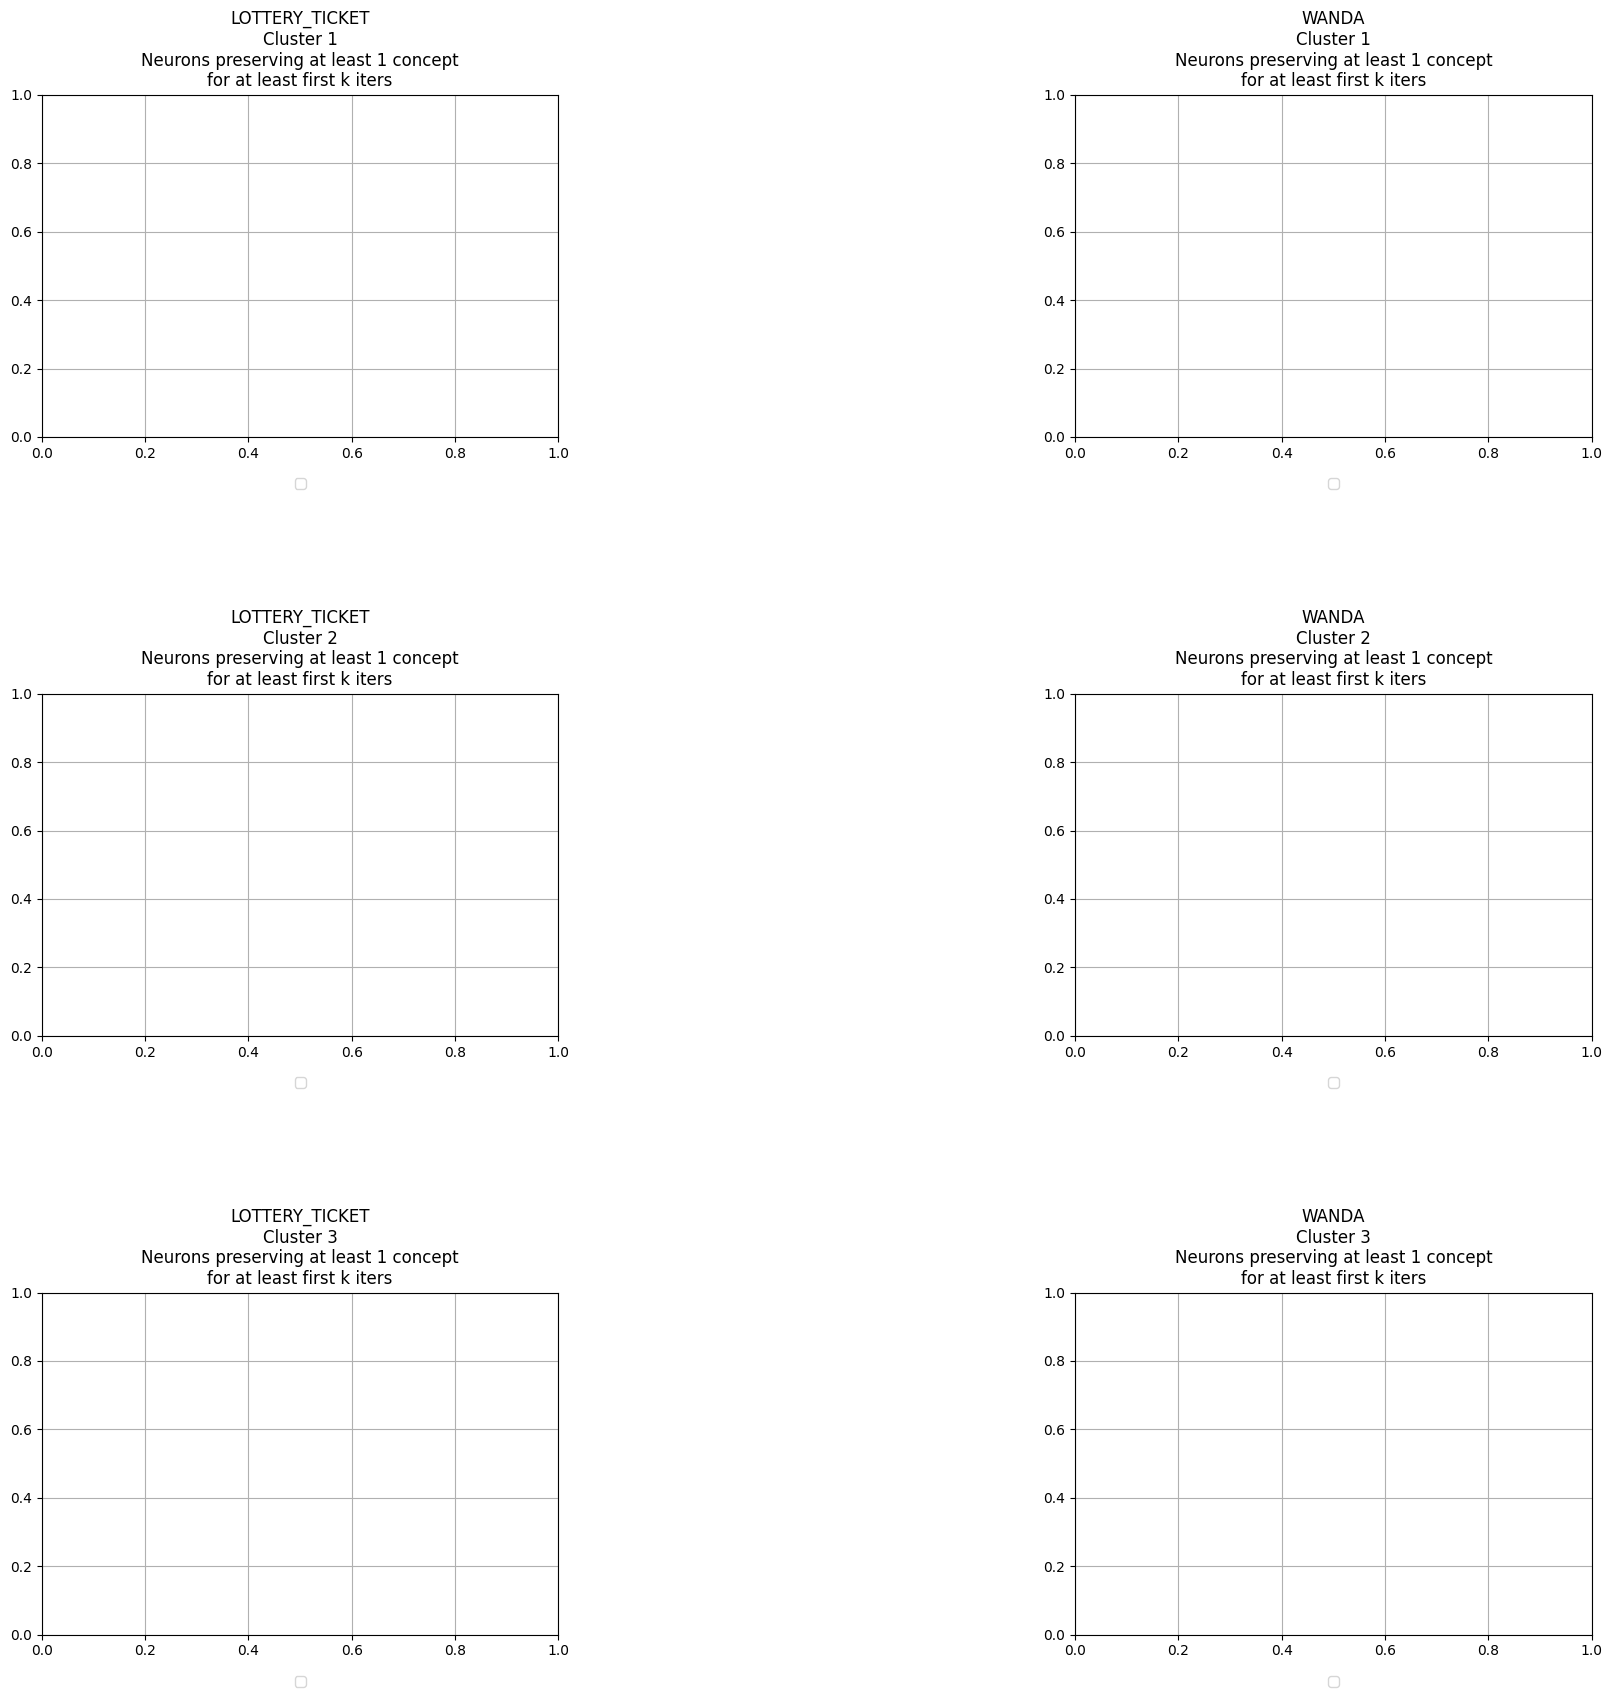

In [8]:
import torch

def get_neurons_explained_originally(model, method, filename, expl_clus):
    unique_concepts=set()
    explanations = {}
    if filename == 'Random':
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Expls/Cluster{expl_clus}IOUS1024N.csv")
    else:
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
    
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    return len(list(all_concept_at_original.keys()))

def get_sparsity_list(model, method, filename):
    sparsities = []
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        sparsities.append(float(sparsity))
    return sorted(sparsities)
        
def dropoff(method, filename, k, **kwargs):
    sparsity_list = get_sparsity_list(model, method, filename)
    num_orig_neurons = kwargs['num_orig_neurons']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    neurons_preserved = [False for i in range(num_orig_neurons)]
    for i,neuron in enumerate(sparsity_mapping.keys()):
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                neurons_preserved[i] = True
                break
    
    return torch.where(torch.tensor(neurons_preserved)==1, 1,0).sum()/num_orig_neurons


params = [{'model':'BERT', 'filename': 'Run0.25'}, {'model':'BOWMAN', 'filename': 'Run0.25'}, {'model':'LLAMA', 'filename': 'Run0.25'}]
results={}
for expl_clus in range(1,4):
    for param in params:
        model = param['model']
        filename = param['filename']
        for method in ['wanda', 'lottery_ticket']:
            percent_preserved_with_dropoff = []
            try: 
                for k in range(1,7):
                    num_orig_neurons = get_neurons_explained_originally(model, method, filename,expl_clus)
                    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list,expl_clus)
                    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename,sparsity_list,expl_clus)
                    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
                    percent_preserved_with_dropoff.append(percent_of_concepts_preserved)
                results[f"{model}_{method}_{filename}_{expl_clus}"] = percent_preserved_with_dropoff
                if model=='BOWMAN' and method=='wanda': print(percent_preserved_with_dropoff)

            except Exception as e:
                print(f"Skipping {model}_{method}_{filename} due to error: {e}")
                
#graph for models and lottery ticket acc


fig, axs = plt.subplots(3,2,figsize=(20, 20))
for expl in range(1,4):
    r=0
    for i, method in enumerate(['lottery_ticket', 'wanda']):
        for model in ['BERT', 'BOWMAN', 'LLAMA']:
            try:
                axs[expl-1][r].plot(sparsity_list, results[f'{model}_{method}_Run0.25_{expl}'], label=model, marker='x')
            except Exception as e:
                print(f"Error in plotting {model}_{method}_Run0.25_{expl} due to {e}")
        axs[expl-1][r].set_title(f'{method.upper()}\nCluster {expl}\nNeurons preserving at least 1 concept\nfor at least first k iters')
        axs[expl-1][r].legend()
        axs[expl-1][r].grid(True)
        axs[expl-1][r].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
        r+=1

fig.subplots_adjust(wspace=1, hspace=0.75)


#65% of neurons preserve concepts for at least 3 pruning iters
#shows that for bert more single neurons preserve concepts 

In [21]:
results[f"{'BOWMAN'}_{'lottery_ticket'}_{'Run0.25'}_{1}"]

[tensor(1.), tensor(0.), tensor(0.), tensor(0.), tensor(0.), tensor(0.)]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Error in plotting BERT due to 'BERT_wanda_Run0.25_1'
Error in plotting BERT due to 'BERT_wanda_Run0.25_2'
Error in plotting BERT due to 'BERT_wanda_Run0.25_3'


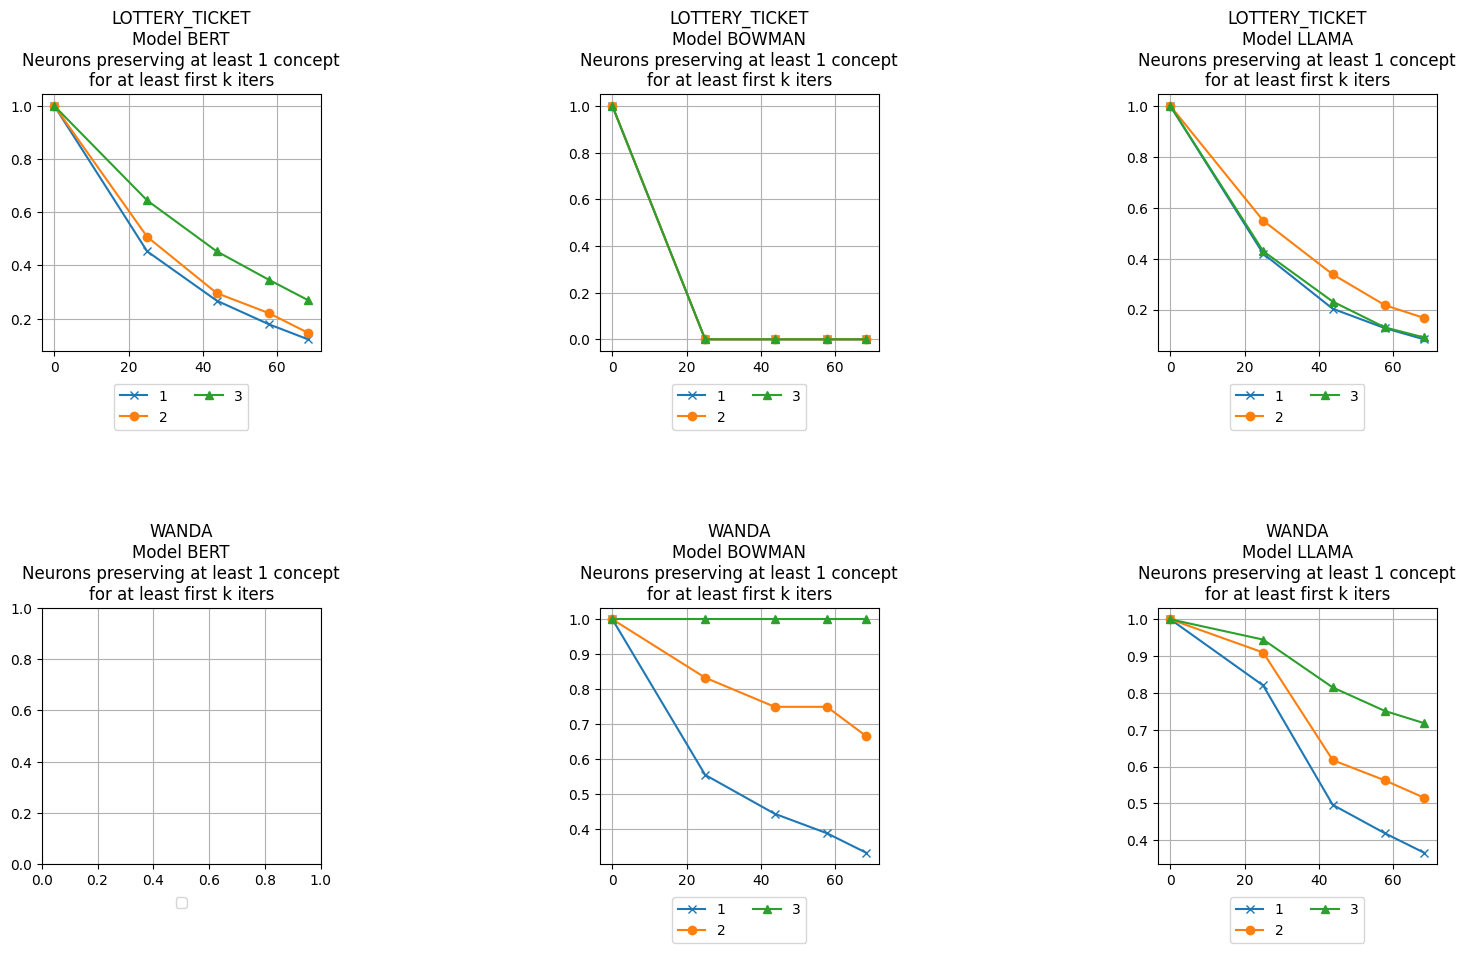

In [150]:
fig, axs = plt.subplots(2, 3, figsize=(18,10))
marker={1:'x', 2:'o', 3:'^', 4:'s'}
for i, method in enumerate(['lottery_ticket', 'wanda']):
    for j,model in enumerate(['BERT', 'BOWMAN', 'LLAMA']):
        for cluster in range(1,4):
            try:
                axs[i][j].plot(sparsity_list[:5], results[f'{model}_{method}_Run0.25_{cluster}'][:5], label=cluster, marker=marker[cluster])
            except Exception as e:
                print(f"Error in plotting {model} due to {e}")
            
        axs[i][j].set_title(f'{method.upper()}\nModel {model}\nNeurons preserving at least 1 concept\nfor at least first k iters')
        axs[i][j].legend()
        axs[i][j].grid(True)
        axs[i][j].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
fig.subplots_adjust(wspace=1, hspace=1)

# global overlap: % of concepts that are preserved in kth pruning iter compared to original

Error in plotting BOWMAN_lottery_ticket_Run0.25_1 due to 'BOWMAN_lottery_ticket_Run0.25_1'
Error in plotting LLAMA_lottery_ticket_Run0.25_1 due to 'LLAMA_lottery_ticket_Run0.25_1'
Error in plotting BOWMAN_wanda_Run0.25_1 due to 'BOWMAN_wanda_Run0.25_1'
Error in plotting LLAMA_wanda_Run0.25_1 due to 'LLAMA_wanda_Run0.25_1'
Error in plotting BOWMAN_lottery_ticket_Run0.25_1 due to 'BOWMAN_lottery_ticket_Run0.25_1'
Error in plotting LLAMA_lottery_ticket_Run0.25_1 due to 'LLAMA_lottery_ticket_Run0.25_1'
Error in plotting BOWMAN_wanda_Run0.25_1 due to 'BOWMAN_wanda_Run0.25_1'
Error in plotting LLAMA_wanda_Run0.25_1 due to 'LLAMA_wanda_Run0.25_1'
Error in plotting BOWMAN_lottery_ticket_Run0.25_2 due to 'BOWMAN_lottery_ticket_Run0.25_2'
Error in plotting LLAMA_lottery_ticket_Run0.25_2 due to 'LLAMA_lottery_ticket_Run0.25_2'
Error in plotting BOWMAN_wanda_Run0.25_2 due to 'BOWMAN_wanda_Run0.25_2'
Error in plotting LLAMA_wanda_Run0.25_2 due to 'LLAMA_wanda_Run0.25_2'
Error in plotting BOWMAN_lot

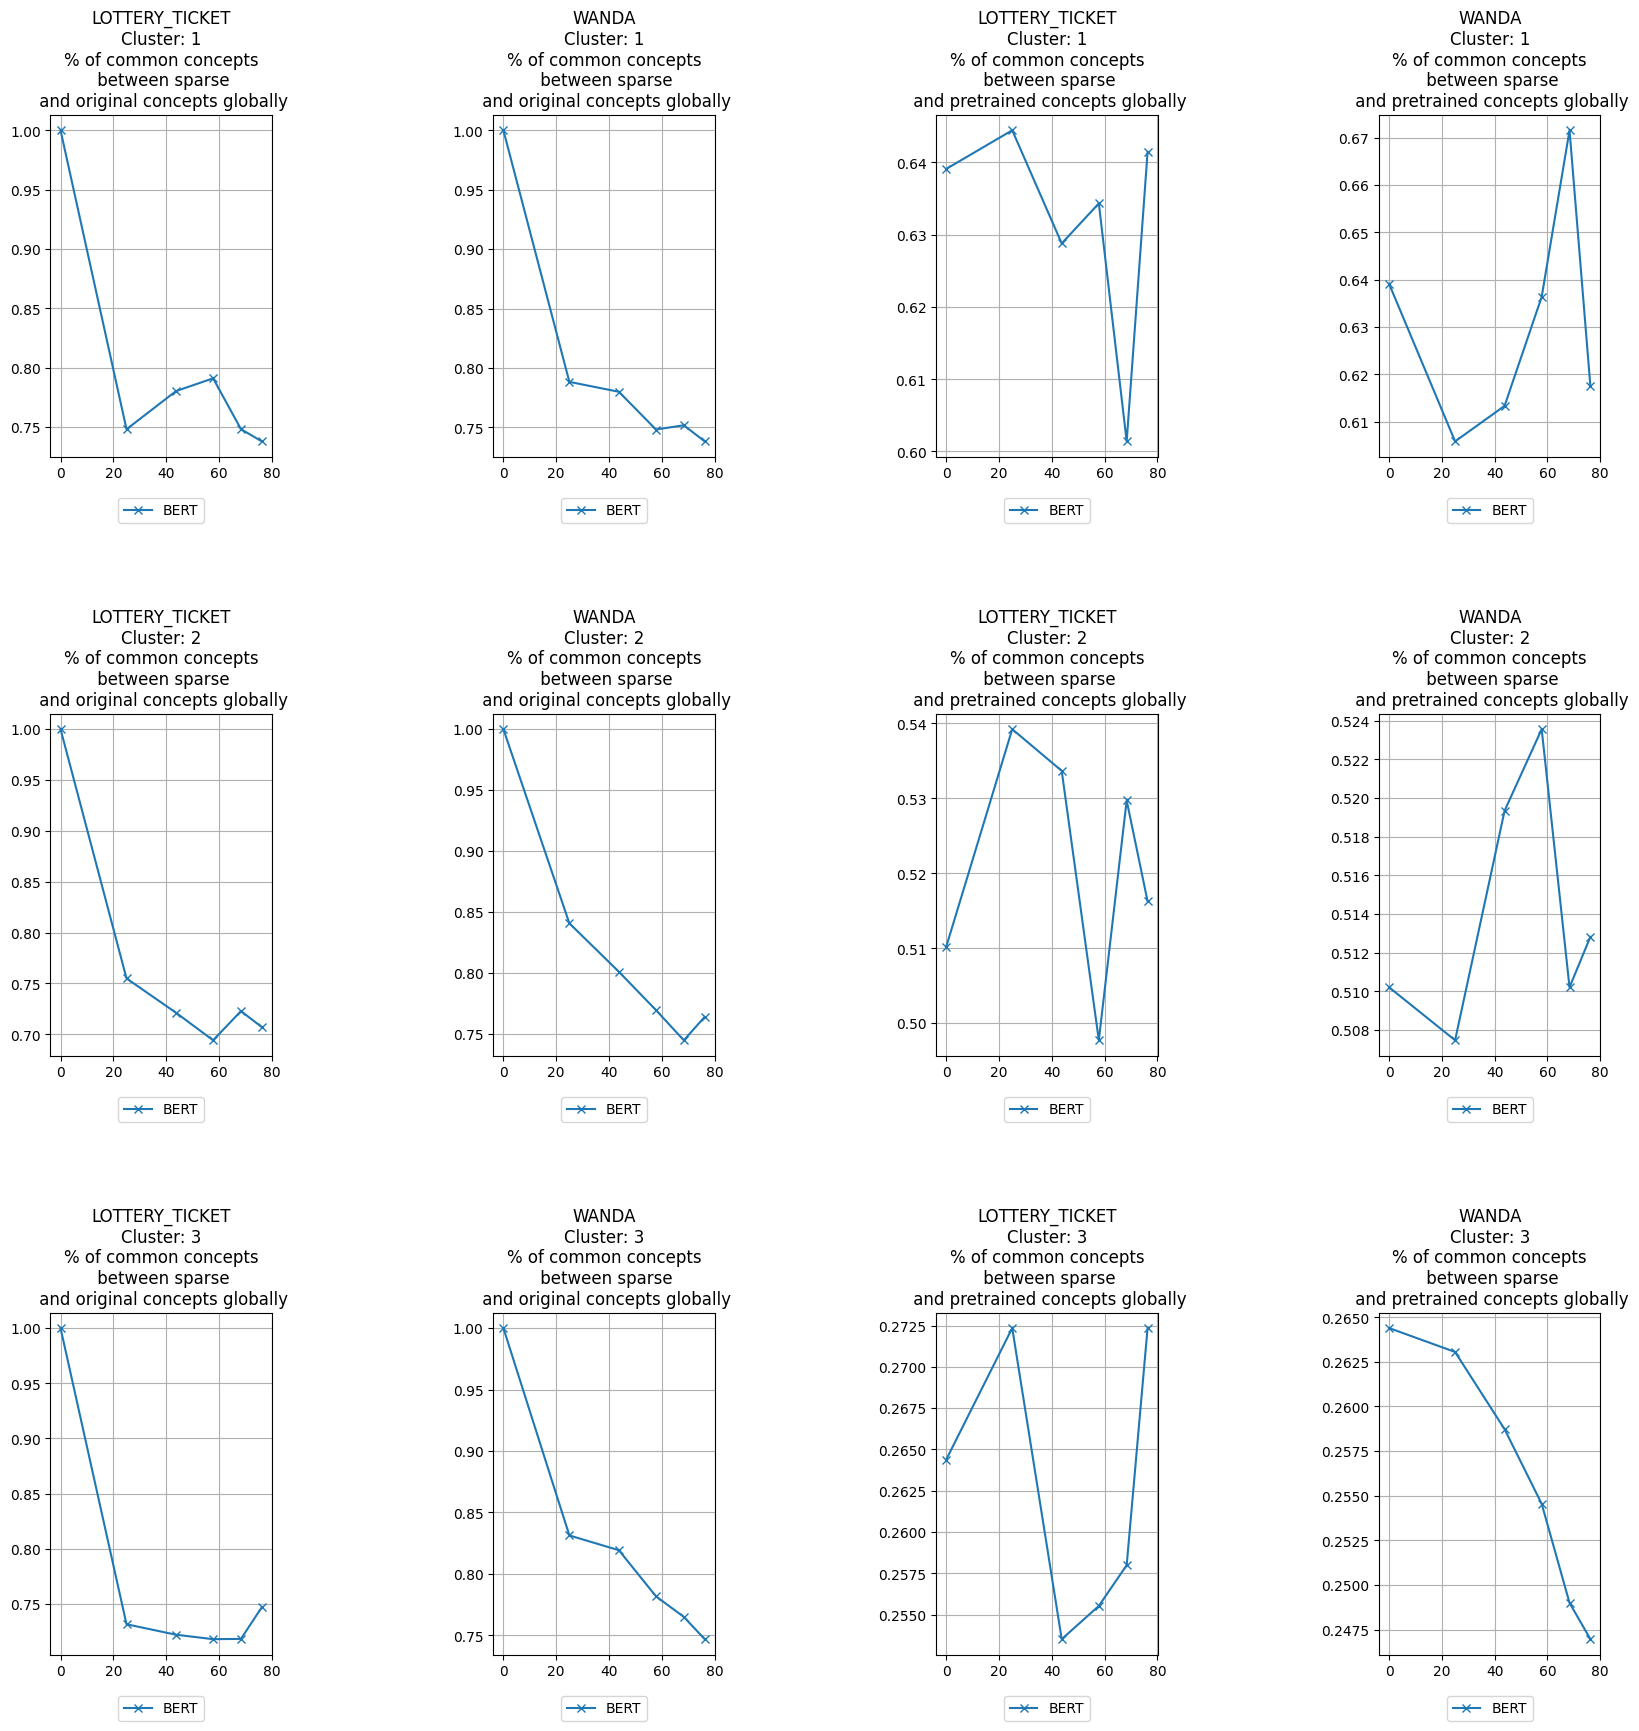

In [14]:
import os
import matplotlib.pyplot as plt
import numpy as np

def get_concepts_across_cluster(model, method, filename,expl_clus):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
    return explanations
def overlap(cur, base):
    
    
    intersection = len(cur.intersection(base))
    union = len(cur.union(base))
    #return percent overlap
    #return intersection/len(base)
    return intersection / len(cur) if union > 0 else 0





pretrained_concepts = set()
for concepts in get_indiv_concepts_per_unit(pd.read_csv(f"/workspace/CCE_NLI/BERT/exp/Pretrained/expls/Cluster{expl_clus}IOUS1024N.csv")).values():
    pretrained_concepts.update(concepts)



params = [{'model':'BERT', 'filename': 'Run0.25'}]#, {'model':'BOWMAN', 'filename': 'Run0.25'}, {'model':'LLAMA', 'filename': 'Run0.25'}]
pretrained_comparison={}
original_comparison={}

for expl_clus in range(1,4):
    for param in params:
        model = param['model']
        filename = param['filename']
        for method in ['wanda', 'lottery_ticket']:
            percent_preserved_with_dropoff = []
            try: 
                pretrained= []
                original = []
                global_concepts = get_concepts_across_cluster(model,method, filename,expl_clus)
                
                base_concepts = global_concepts[0.0]
                for i, sparsity in enumerate(global_concepts):
                    if not original or i >= len(original):
                        original.append(overlap(global_concepts[sparsity], base_concepts))
                    else:
                        original[i] += overlap(global_concepts[sparsity], base_concepts)

                    if not pretrained or i >= len(pretrained):
                        pretrained.append(overlap(global_concepts[sparsity], pretrained_concepts))
                    else:
                        pretrained[i] += overlap(global_concepts[sparsity], pretrained_concepts)

                pretrained_comparison[f"{model}_{method}_{filename}_{expl_clus}"] = pretrained
                original_comparison[f"{model}_{method}_{filename}_{expl_clus}"] = original


            except Exception as e:
                print(f"Skipping {model}_{method}_{filename} due to error: {e}")
            
sparsity_list = [0.0, 25.0, 43.75, 57.81, 68.36, 76.27]
#graph for models and lottery ticket acc
fig, axs = plt.subplots(3,4,figsize=(20, 20))
for expl in range(1,4):
    r=0
    for j, comp in enumerate(['original', 'pretrained']):
        if j == 0:
            ds = original_comparison
        else:
            ds = pretrained_comparison
        for i, method in enumerate(['lottery_ticket', 'wanda']):
            for model in ['BERT', 'BOWMAN', 'LLAMA']:
                try:
                    axs[expl-1][r].plot(sparsity_list, ds[f'{model}_{method}_Run0.25_{expl}'], label=model, marker='x')
                except Exception as e:
                    print(f"Error in plotting {model}_{method}_Run0.25_{expl} due to {e}")
            axs[expl-1][r].set_title(f'{method.upper()}\nCluster: {expl}\n% of common concepts\n between sparse\n and {comp} concepts globally')
            axs[expl-1][r].legend()
            axs[expl-1][r].grid(True)
            axs[expl-1][r].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
            r+=1
            
fig.subplots_adjust(wspace=1, hspace=0.75)



            



NameError: name 'original_comparison' is not defined

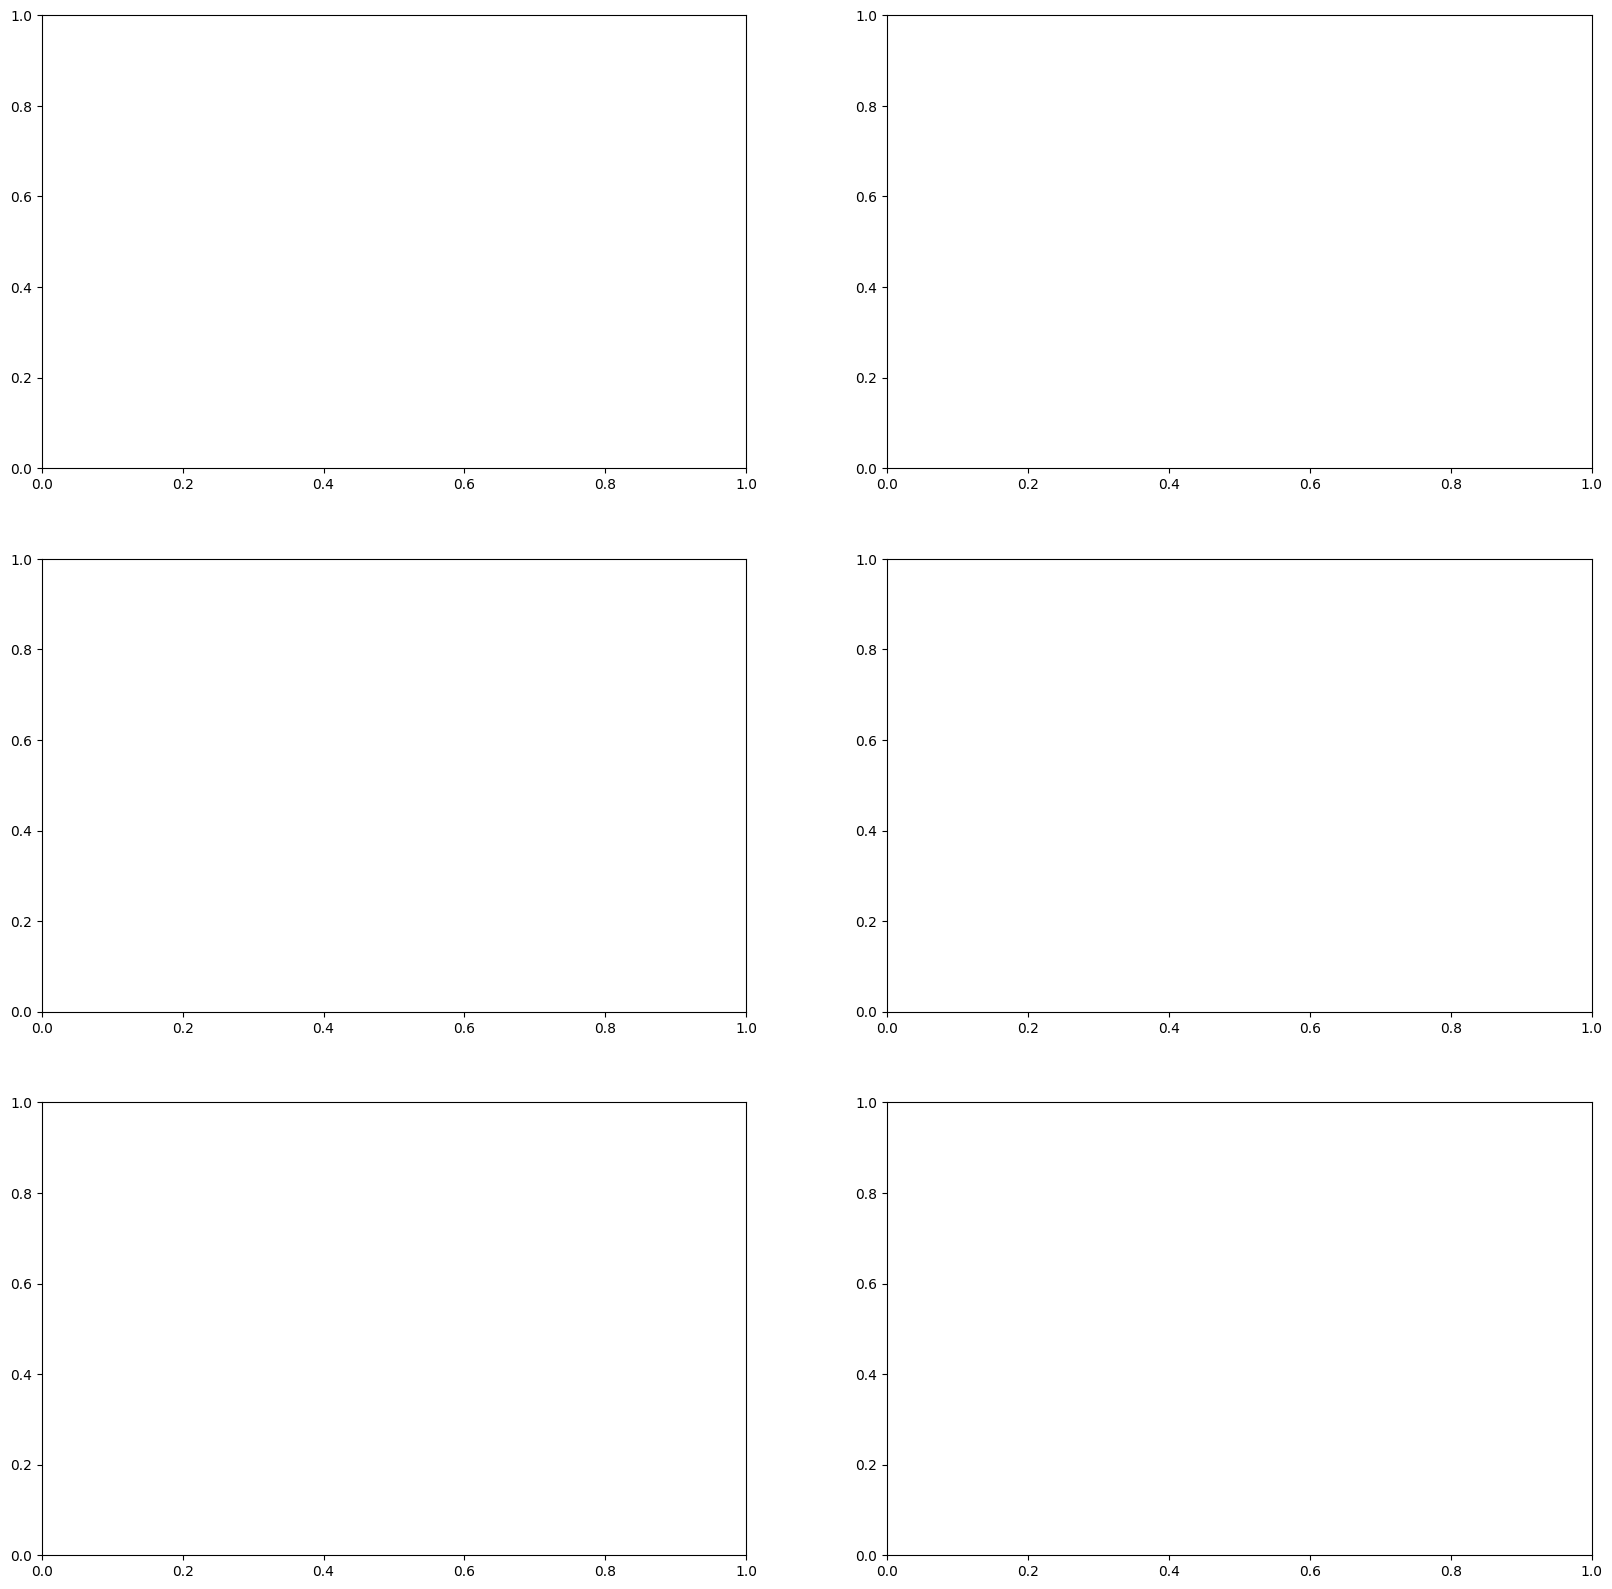

In [5]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3,2,figsize=(20, 20))
for row, model in enumerate(['BERT']):# 'BOWMAN' 'LLAMA']):
    for j, comp in enumerate(['original']):
        for i, method in enumerate(['lottery_ticket', 'wanda']):
            for expl in range(1,4):
                if j == 0:
                    ds = original_comparison
                else:
                    ds = pretrained_comparison
                try:
                    axs[row][i].plot(sparsity_list, ds[f'{model}_{method}_Run0.25_{expl}'], label=expl, marker='x')
                except Exception as e:
                    print(f"Error in plotting {model}_{method}_Run0.25_{expl} due to {e}")
            
                axs[row][i].set_title(f'{method.upper()}\nModel: {model}\n% of common concepts\n between sparse\n and {comp} concepts globally')
                axs[row][i].legend()
                axs[row][i].grid(True)
                axs[row][i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
      
            
fig.subplots_adjust(wspace=1, hspace=0.75)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

Error in plotting BERT_wanda_Run0.25_1 due to x and y must have same first dimension, but have shapes (6,) and (5,)
Error in plotting BERT_wanda_Run0.25_2 due to 'BERT_wanda_Run0.25_2'
Error in plotting BERT_wanda_Run0.25_3 due to 'BERT_wanda_Run0.25_3'
Error in plotting BOWMAN_wanda_Run0.25_1 due to 'BOWMAN_wanda_Run0.25_1'
Error in plotting BOWMAN_wanda_Run0.25_2 due to 'BOWMAN_wanda_Run0.25_2'
Error in plotting BOWMAN_wanda_Run0.25_3 due to 'BOWMAN_wanda_Run0.25_3'


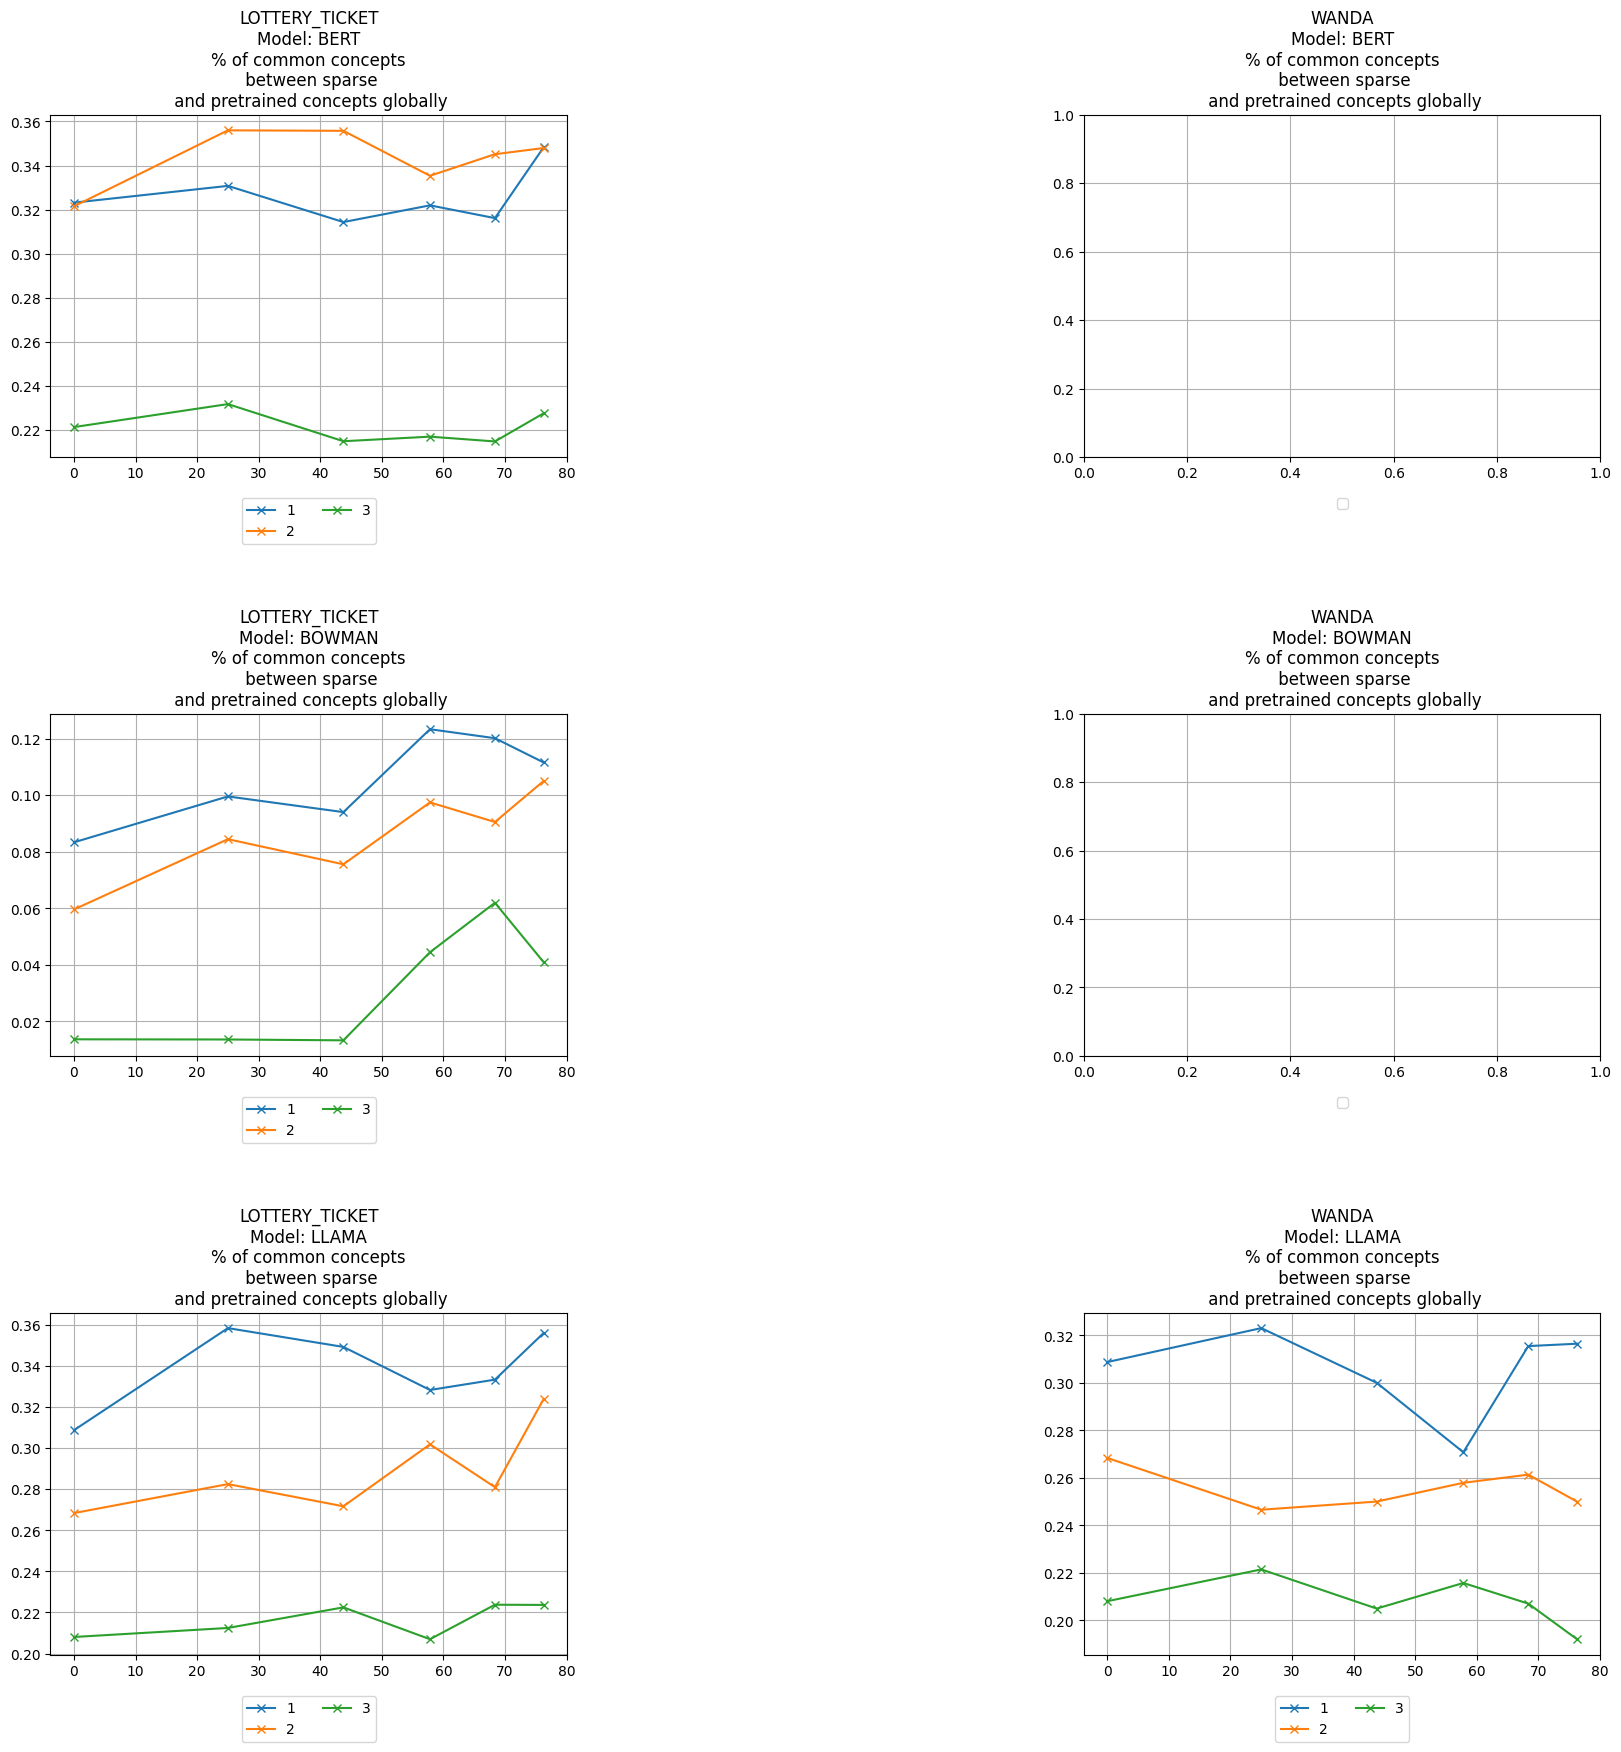

In [14]:
fig, axs = plt.subplots(3,2,figsize=(20, 20))
for row, model in enumerate(['BERT', 'BOWMAN', 'LLAMA']):
    for j, comp in enumerate(['pretrained']):
        for i, method in enumerate(['lottery_ticket', 'wanda']):
            for expl in range(1,4):
                if j == 0:
                    ds = pretrained_comparison
                else:
                    ds = pretrained_comparison
                try:
                    axs[row][i].plot(sparsity_list, ds[f'{model}_{method}_Run0.25_{expl}'], label=expl, marker='x')
                except Exception as e:
                    print(f"Error in plotting {model}_{method}_Run0.25_{expl} due to {e}")
            
                axs[row][i].set_title(f'{method.upper()}\nModel: {model}\n% of common concepts\n between sparse\n and {comp} concepts globally')
                axs[row][i].legend()
                axs[row][i].grid(True)
                axs[row][i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
      
            
fig.subplots_adjust(wspace=1, hspace=0.75)

67 is where wanda acc drops down to 33% and thats where the overlap with the default starts losing consistency 
as acc drops the wanda alignemnt w default increases then when the acc plateaus staying around 33 the alignment with default rules fluctuates

lottery consistently has lower alginment with default 

this is global alignment what about neuron wise alignemnt (do next cl


In [145]:
c1_default=get_indiv_concepts_per_unit(pd.read_csv('/workspace/CCE_NLI/BERT/exp/PretrainedWeights/expls/Cluster3IOUS1024N.csv'))
#c2_default=get_indiv_concepts_per_unit(pd.read_csv('/workspace/CCE_NLI/BERT/exp/PretrainedWeights/expls/Cluster2IOUS1024N.csv')                                        
#c3_default=get_indiv_concepts_per_unit(pd.read_csv('/workspace/CCE_NLI/BERT/exp/PretrainedWeights/expls/Cluster3IOUS1024N.csv')                                        

In [146]:
method='wanda'
filename='Run3'
model='BERT'
expl_clus=3
neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list,expl_clus)

In [147]:
default_local_iou=collections.defaultdict(float)
for neuron in c1_default.keys():
    for spars in  sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/")):
        spars=float(spars.split("%")[0])
        if spars in neuron_concept_sparsity_mapping[neuron]:
            default_local_iou[spars] += overlap(set(neuron_concept_sparsity_mapping[neuron][spars]), set(c1_default[neuron]))
default_local_iou=[i/len(c1_default) for i in default_local_iou.values()]

In [148]:
default_local_iou

[0.004689625850340136,
 0.0028932823129251698,
 0.0011054421768707484,
 0.0013881802721088434,
 0.0047619047619047615,
 0.003273809523809524,
 0.003125,
 0.003422619047619047,
 0.005465561224489796,
 0.006252125850340137,
 0.010559807256235829,
 0.012576530612244898,
 0.007937925170068028,
 0.011212443310657596]

In [123]:

df=pd.read_csv("/workspace/CCE_NLI/BERT/exp/PretrainedWeights/Expls/Cluster3IOUS1024N.csv")
default_cps_per_neuron = get_indiv_concepts_per_unit(df)


In [102]:
len(global_concepts_lth[91.41]), len(pretrained_concepts)

(373, 215)

Skipping BERT_wanda_Run0.25 due to error: [Errno 2] No such file or directory: '/workspace/CCE_NLI/BERT/exp/wanda/Run0.25/Expls/68.359%Pruned/Cluster3IOUS1024N.csv'


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Error in plotting BERT due to shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (6,) and arg 1 with shape (4,).


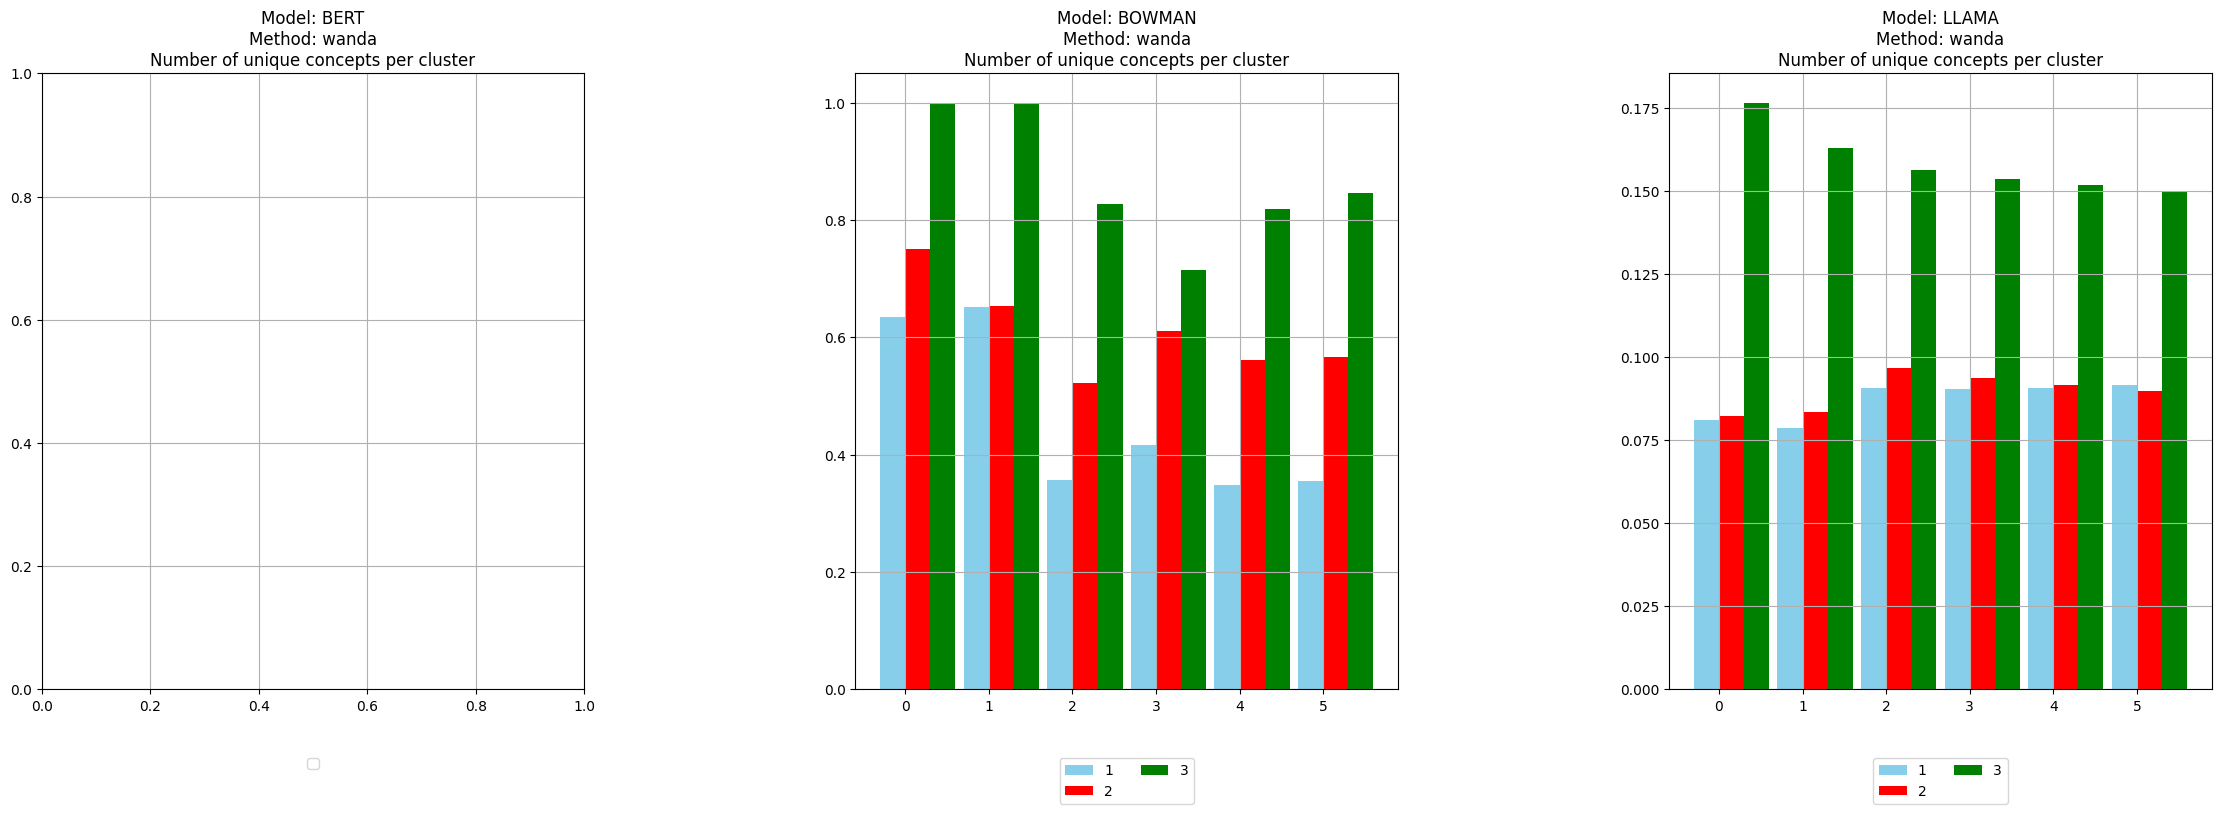

In [72]:
expl_clus=1
def get_number_of_unique_concepts_global(df):
    concepts=set()
    total = []
    for neuron,expls in get_indiv_concepts_per_unit(df).items():
        concepts.update(expls)
        total.extend(expls)
    return len(concepts), len(total)

def get_num_concepts_across_cluster(model, method, filename,expl_clus):
    explanations = []
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        num_unique, total = get_number_of_unique_concepts_global(cluster3_expls)
        explanations.append(num_unique/total)
    return explanations
import numpy as np




bar_width = 0.3

fig, axs = plt.subplots(1, 3, figsize=(28, 8))
params = [{'model':'BERT', 'filename': 'Run0.25'}, {'model':'BOWMAN', 'filename': 'Run0.25'}, {'model':'LLAMA', 'filename': 'Run0.25'}]
results={}
for expl_clus in range(1,4):
    for param in params:
        model = param['model']
        filename = param['filename']
        for method in ['wanda', 'lottery_ticket']:
            percent_preserved_with_dropoff = []
            try: 


                results[f"{model}_{method}_{filename}_{expl_clus}"] = get_num_concepts_across_cluster(model, method, filename, expl_clus)

            except Exception as e:
                print(f"Skipping {model}_{method}_{filename} due to error: {e}")

#graph for models and lottery ticket acc
methods = ['lottery_ticket', 'wanda']
for i, model in enumerate(['BERT', 'BOWMAN', 'LLAMA']):
    try:
        
        x_axis=get_sparsities(model, method, filename)   
        x_pos = np.arange(len(x_axis))  # Numeric positions for bars
        axs[i].bar(x_pos - bar_width/2, get_num_concepts_across_cluster(model, methods[1], filename, 1), label=f'{1}', color='skyblue', width=bar_width)
        axs[i].bar(x_pos + bar_width/2, get_num_concepts_across_cluster(model, methods[1], filename, 2), label=f'{2}', color='red', width=bar_width)
        axs[i].bar(x_pos + 1.5*bar_width, get_num_concepts_across_cluster(model, methods[1], filename, 3), label=f'{3}', color='green', width=bar_width)
    except Exception as e:
        print(f"Error in plotting {model} due to {e}")

    axs[i].set_title(f'Model: {model}\nMethod: {methods[1]}\nNumber of unique concepts per cluster')
    axs[i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

    axs[i].grid(True)

fig.subplots_adjust(wspace=0.5, hspace=0.5)


In [70]:
#every iteration is 55% similar to the concepts in the original
#with wanda its expectedly reducing in similar (wb increase at 86)
model='BERT'        
method='wanda'
filename='Run3'
get_num_concepts_across_cluster(model, method, filename)

[0.07176622260421144,
 0.07494646680942184,
 0.08139534883720931,
 0.08381782945736434,
 0.13155021834061134,
 0.1698943661971831,
 0.18915510718789408,
 0.17355371900826447,
 0.16862745098039217,
 0.16236559139784945,
 0.1359918200408998,
 0.12605042016806722,
 0.11633875106929,
 0.11075697211155379]

# global overlap: % of concepts in prev that carry over to next

0 137 0.0
108 179 0.6033519553072626
115 178 0.6460674157303371
110 170 0.6470588235294118
0 137 0.0
Skipping BERT_wanda_Run0.25 due to error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (4,) and arg 1 with shape (5,).
133 133 1.0
101 167 0.6047904191616766
98 169 0.5798816568047337
104 162 0.6419753086419753
105 172 0.6104651162790697
111 177 0.6271186440677966
33 33 1.0
18 60 0.3
36 140 0.2571428571428571
69 165 0.41818181818181815
76 190 0.4
82 211 0.3886255924170616
32 32 1.0
18 53 0.33962264150943394
20 60 0.3333333333333333
21 60 0.35
24 62 0.3870967741935484
24 66 0.36363636363636365
175 175 1.0
134 211 0.6350710900473934
124 247 0.5020242914979757
154 245 0.6285714285714286
161 239 0.6736401673640168
157 246 0.6382113821138211
175 175 1.0
121 218 0.555045871559633
119 197 0.6040609137055838
108 181 0.5966850828729282
110 176 0.625
114 178 0.6404494382022472


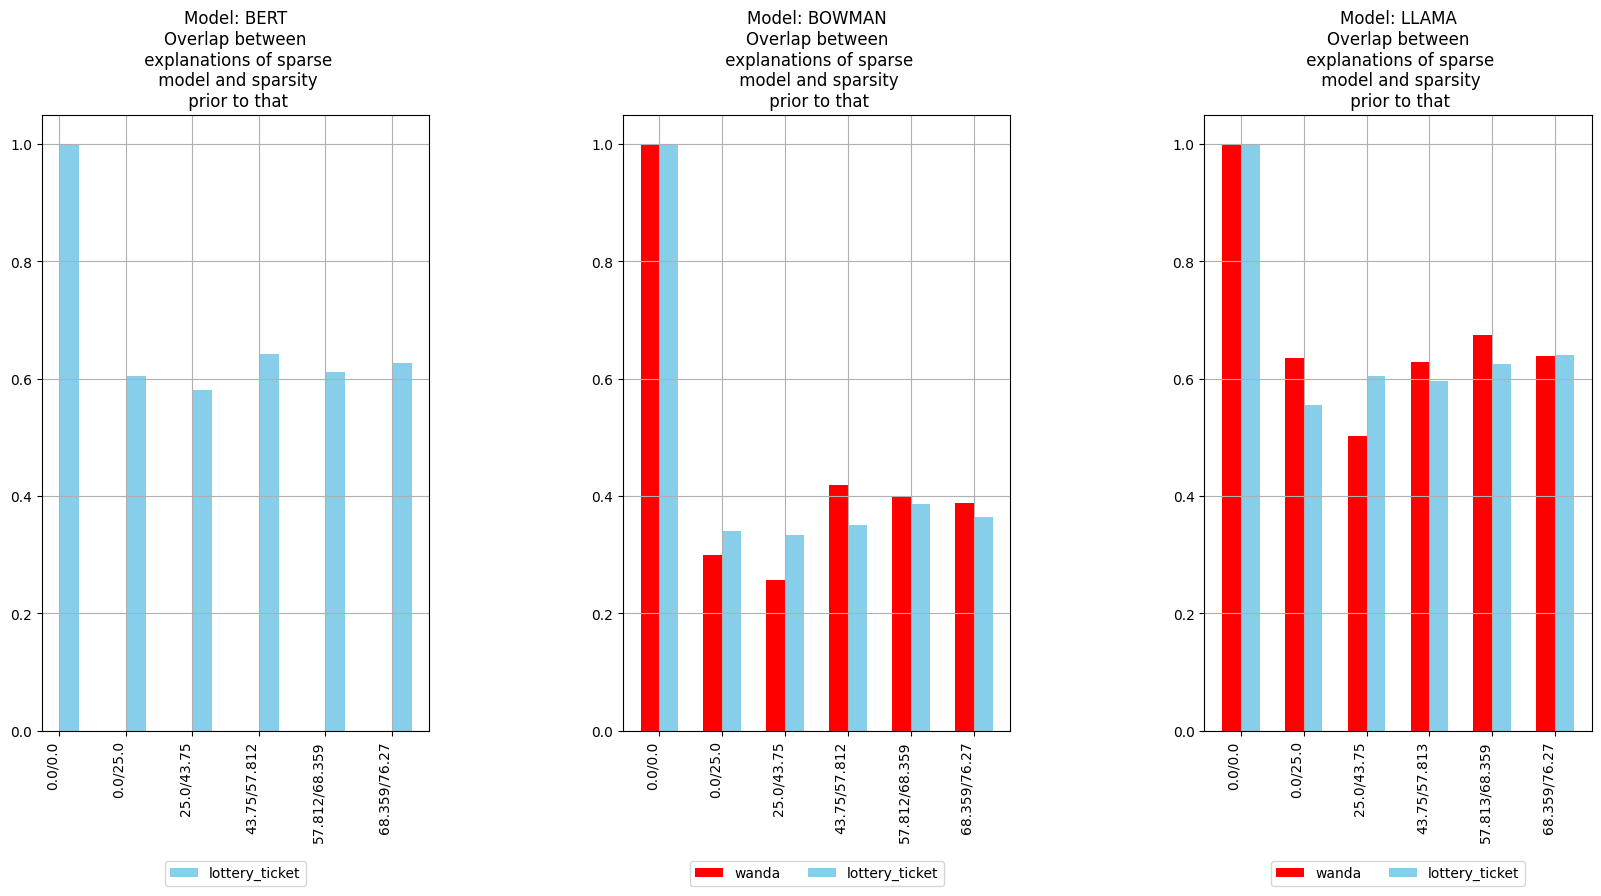

In [63]:
def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
        
        if float(sparsity) >= 82 and float(sparsity) <= 87:
            print(method, sparsity, len(explanations[float(sparsity)]))
    return explanations

def overlap(cur, prev):
    intersection = len(cur.intersection(prev))
    union = len(cur.union(prev))
    print(intersection, union, intersection/union)
    
    return intersection / union if union > 0 else 0



import numpy as np



bar_width = 0.3

fig, axs = plt.subplots(1, 3, figsize=(20, 8))
params = [{'model':'BERT', 'filename': 'Run0.25'}, {'model':'BOWMAN', 'filename': 'Run0.25'}, {'model':'LLAMA', 'filename': 'Run0.25'}]
color = {'wanda': 'red', 'lottery_ticket': 'skyblue'}
results={}
for idx, param in enumerate(params):
    factor = -1
    
    model = param['model']
    filename = param['filename']
    for method in ['wanda', 'lottery_ticket']:
        factor *= -1
        concept_overlap = []
        try: 
            global_concepts = get_concepts_across_cluster(model, method, filename)
            sps = list(global_concepts.keys())
            base_concepts = global_concepts[0.0]
            x_axis=get_sparsities(model, method, filename)   
            x = ["0.0/0.0"]+[f"{x_axis[j]}/{x_axis[j+1]}" for j in range(len(x_axis) - 1)]        
            x_pos = np.arange(len(x))  #
            
            for i,sparsity in enumerate(global_concepts.keys()):
                if i-1 >= 0:
                    concept_overlap.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
                else:
                    concept_overlap.append(overlap(global_concepts[sparsity], base_concepts))
              
            axs[idx].bar(x_pos - (factor*bar_width/2), concept_overlap, label=f'{method}', color=color[method], width=bar_width)

            axs[idx].set_xticks(x_pos)
            axs[idx].set_xticklabels(x, rotation=90, ha='right')
            axs[idx].set_title(f'Model: {model}\nOverlap between\n explanations of sparse\n model and sparsity\n prior to that')
            axs[idx].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)

            axs[idx].grid(True)
            
        except Exception as e:
            print(f"Skipping {model}_{method}_{filename} due to error: {e}")


fig.subplots_adjust(wspace=0.5, hspace=0.5)




In [ ]:
#every subseq iteration has rougly 60% of concepts preserved fromthe prev iter lthbert

#bowman 30% overlap between subseq pruning iters
bowman looses more concepts with pruning? or at least it doesnt preserve concepts as bert does cuz global overalp is very low
and locally after pruning % of concepts preserved drastially drops

the increase at 83/86 means those sparsities expl more sim cps than 79/83